In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Better plot appearance
sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("/content/student_performance.csv")

df.head()

,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3
1,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2
2,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0
3,19,64,1,1,0,1,0,19,2,8,1,59,40,0,1,3
4,19,64,1,1,0,1,0,23,3,16,0,90,66,0,1,2


In [4]:
print("Rows and Columns:")
print(df.shape)

Rows and Columns:
(14003, 16)


In [5]:
print(df.columns)

Index(['StudyHours', 'Attendance', 'Resources', 'Extracurricular',
       'Motivation', 'Internet', 'Gender', 'Age', 'LearningStyle',
       'OnlineCourses', 'Discussions', 'AssignmentCompletion', 'ExamScore',
       'EduTech', 'StressLevel', 'FinalGrade'],
      dtype='object')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14003 entries, 0 to 14002
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   StudyHours            14003 non-null  int64
 1   Attendance            14003 non-null  int64
 2   Resources             14003 non-null  int64
 3   Extracurricular       14003 non-null  int64
 4   Motivation            14003 non-null  int64
 5   Internet              14003 non-null  int64
 6   Gender                14003 non-null  int64
 7   Age                   14003 non-null  int64
 8   LearningStyle         14003 non-null  int64
 9   OnlineCourses         14003 non-null  int64
 10  Discussions           14003 non-null  int64
 11  AssignmentCompletion  14003 non-null  int64
 12  ExamScore             14003 non-null  int64
 13  EduTech               14003 non-null  int64
 14  StressLevel           14003 non-null  int64
 15  FinalGrade            14003 non-null  int64
dtypes: i

In [7]:
df.isnull().sum()

,0
StudyHours,0
Attendance,0
Resources,0
Extracurricular,0
Motivation,0
Internet,0
Gender,0
Age,0
LearningStyle,0
OnlineCourses,0


In [8]:
duplicate_count = df.duplicated().sum()

print("Duplicate Rows:", duplicate_count)

duplicate_percentage = (duplicate_count / len(df)) * 100

print("Percentage of Duplicates:", round(duplicate_percentage,2), "%")

Duplicate Rows: 1534
Percentage of Duplicates: 10.95 %


In [9]:
df.describe()

,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
count,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.00000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000
mean,19.987431,80.194316,1.104406,0.594158,0.905806,0.925516,0.551953,23.532172,1.515461,9.891952,0.60587,74.502535,70.346926,0.709062,1.304363,1.447904
std,5.890637,11.472181,0.697362,0.491072,0.695896,0.262566,0.497311,3.514293,1.112941,6.112801,0.48868,14.632177,17.688113,0.454211,0.785383,1.121550
min,5.000000,60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,0.000000,0.000000,0.00000,50.000000,40.000000,0.000000,0.000000,0.000000
25%,16.000000,70.000000,1.000000,0.000000,0.000000,1.000000,0.000000,20.000000,1.000000,5.000000,0.00000,62.000000,55.000000,0.000000,1.000000,0.000000
50%,20.000000,80.000000,1.000000,1.000000,1.000000,1.000000,1.000000,24.000000,2.000000,10.000000,1.00000,74.000000,70.000000,1.000000,2.000000,1.000000
75%,24.000000,90.000000,2.000000,1.000000,1.000000,1.000000,1.000000,27.000000,3.000000,15.000000,1.00000,87.000000,86.000000,1.000000,2.000000,2.000000
max,44.000000,100.000000,2.000000,1.000000,2.000000,1.000000,1.000000,29.000000,3.000000,20.000000,1.00000,100.000000,100.000000,1.000000,2.000000,3.000000


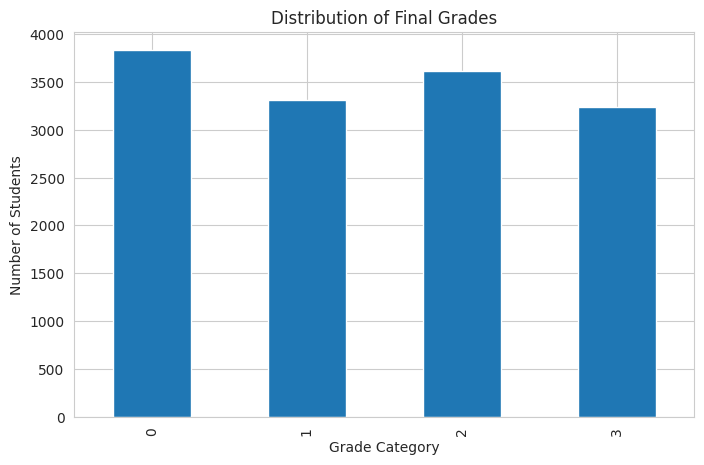

In [10]:
plt.figure(figsize=(8,5))

df["FinalGrade"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Final Grades")
plt.xlabel("Grade Category")
plt.ylabel("Number of Students")

plt.show()

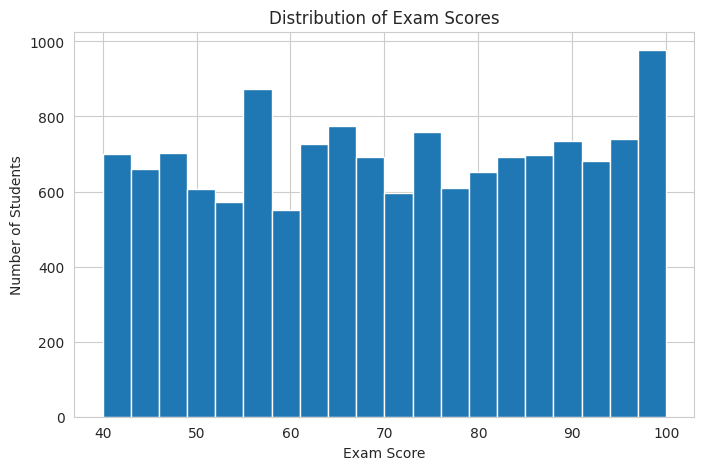

In [11]:
plt.figure(figsize=(8,5))

plt.hist(df["ExamScore"], bins=20)

plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")

plt.show()

In [12]:
corr = df.corr(numeric_only=True)

corr["FinalGrade"].sort_values(ascending=False)

,FinalGrade
FinalGrade,1.000000
Discussions,0.039741
StressLevel,0.037786
Attendance,0.010870
Extracurricular,0.010560
Internet,0.006345
Age,0.002903
Motivation,0.002726
Resources,-0.002907
StudyHours,-0.009623


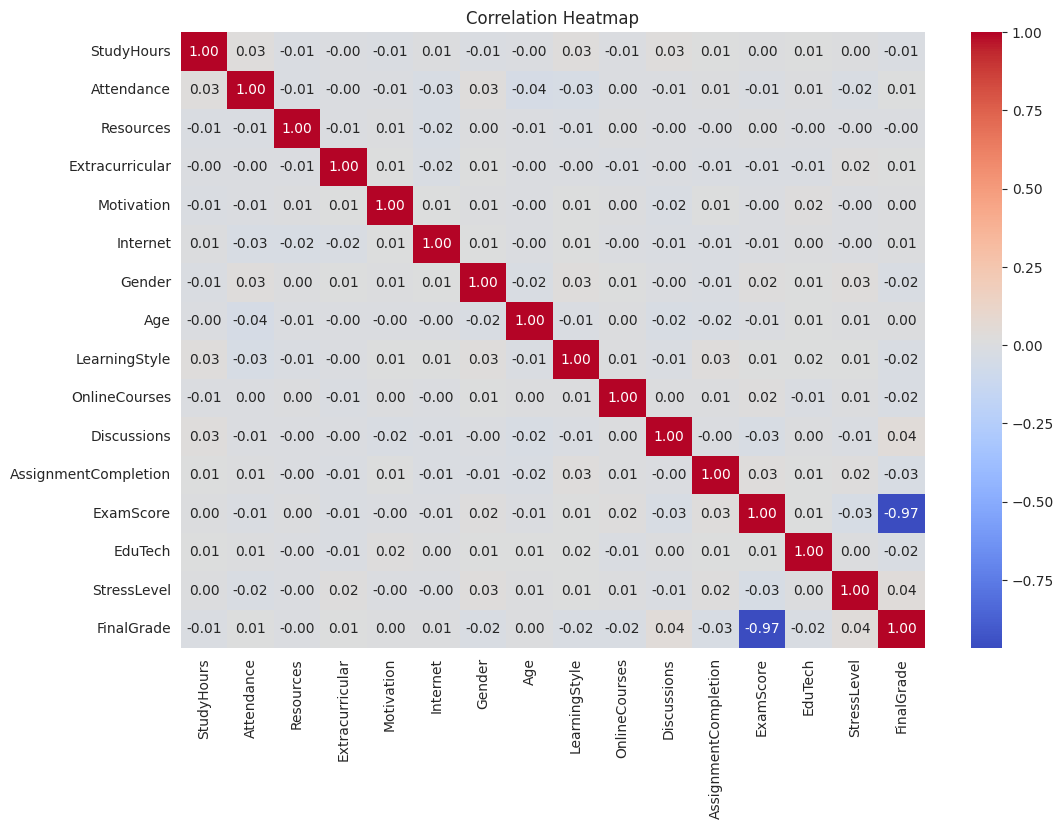

In [13]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

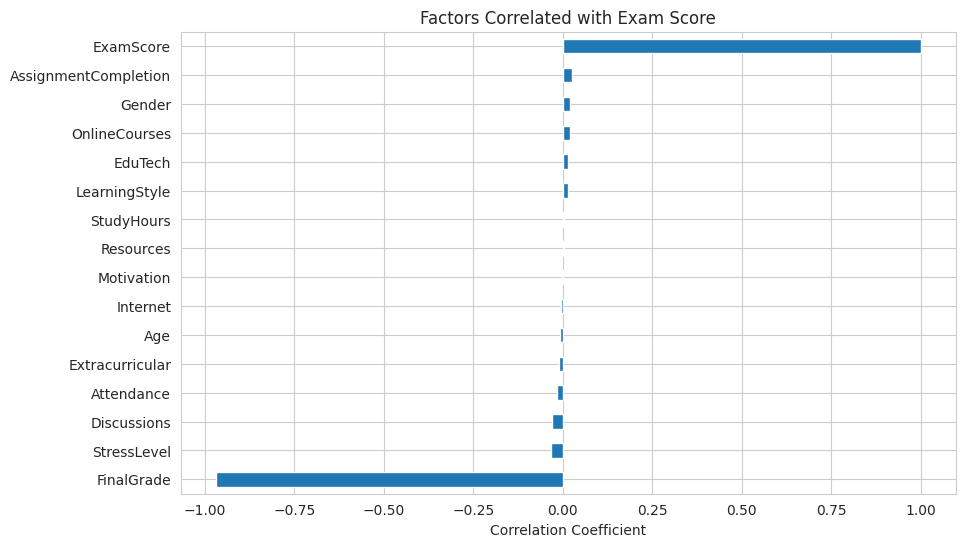

In [14]:
corr_exam = corr["ExamScore"].sort_values()

plt.figure(figsize=(10,6))

corr_exam.plot(kind="barh")

plt.title("Factors Correlated with Exam Score")
plt.xlabel("Correlation Coefficient")

plt.show()

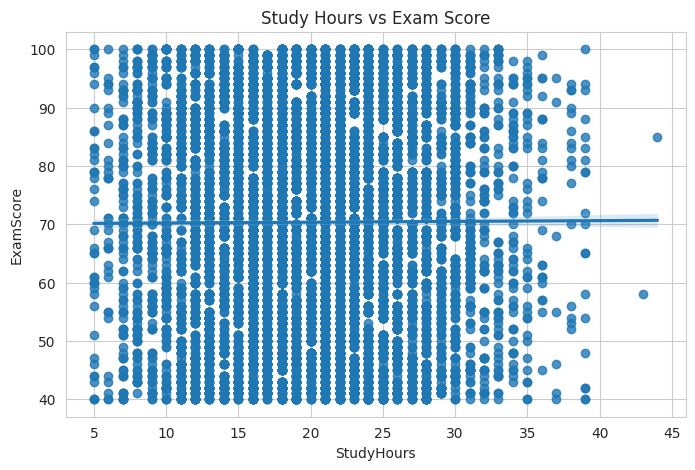

In [15]:
plt.figure(figsize=(8,5))

sns.regplot(
    x="StudyHours",
    y="ExamScore",
    data=df
)

plt.title("Study Hours vs Exam Score")

plt.show()

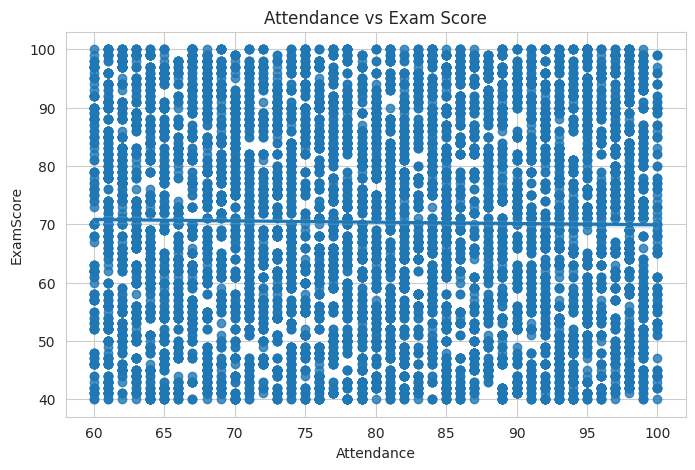

In [16]:
plt.figure(figsize=(8,5))

sns.regplot(
    x="Attendance",
    y="ExamScore",
    data=df
)

plt.title("Attendance vs Exam Score")

plt.show()

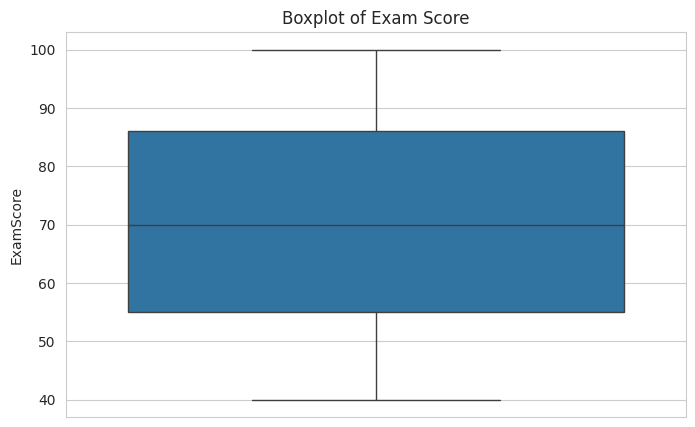

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df["ExamScore"])

plt.title("Boxplot of Exam Score")

plt.show()